The Iris dataset is one of the most well-known datasets in machine learning and statistics. It contains 150 samples of iris flowers from three different species (Setosa, Versicolor, and Virginica), with four numerical features: sepal length, sepal width, petal length, and petal width.Although the dataset includes the true species labels, in this project we will treat it as an unsupervised learning problem. Our goal is to apply the K-Means clustering algorithm to group the flowers based only on their measurements, without using the labels during training. We will later use the true labels only for evaluation and comparison.

![Iris Dataset](ircs.jpg)

In [1]:
# source image:https://miro.medium.com/max/2550/0*GVjzZeYrir0R_6-X.png

import libraries

In [2]:
from pandas import read_csv, DataFrame, crosstab
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Read dataset

In [4]:
dataframe = read_csv('IRIS.csv')
dataframe

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
display(dataframe.shape)

(150, 5)

In [6]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [7]:
display(dataframe.describe())

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
dataframe.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [9]:
#-------------------------
## Check if Null Values / Duplicated Values
#------------------------
print(f'Count of Duplicated Values {dataframe.duplicated().sum()}')
print(f'Count of Non Values {dataframe.isna().sum()}')


Count of Duplicated Values 3
Count of Non Values sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [10]:
#-------------------------
## Remove Duplicated Values
#------------------------
dataframe.drop_duplicates(inplace=True)
print(f'Count of Duplicated Values {dataframe.duplicated().sum()}')


Count of Duplicated Values 0


<Axes: xlabel='species', ylabel='Count'>

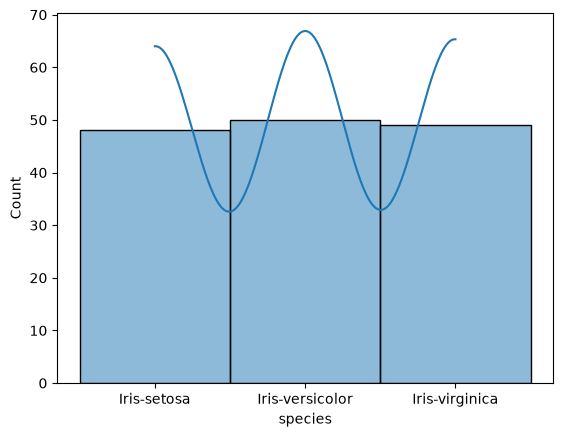

In [11]:
#-------------------------
## Histogram Visualization Before Scaling
#------------------------
sns.histplot(data = dataframe, x = "species", kde = True)

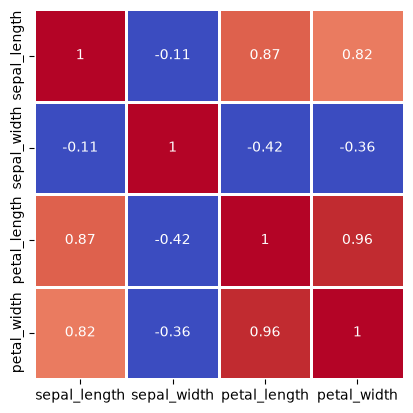

In [12]:
#-------------------------
## HeatMap Visualization Before Scaling
#------------------------
data_frame = dataframe.drop(columns='species')
corr = data_frame.corr()
ax1 = sns.heatmap(corr, cbar=0, linewidths=2,vmax=1, vmin=0, square=True, cmap='coolwarm',annot=True)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


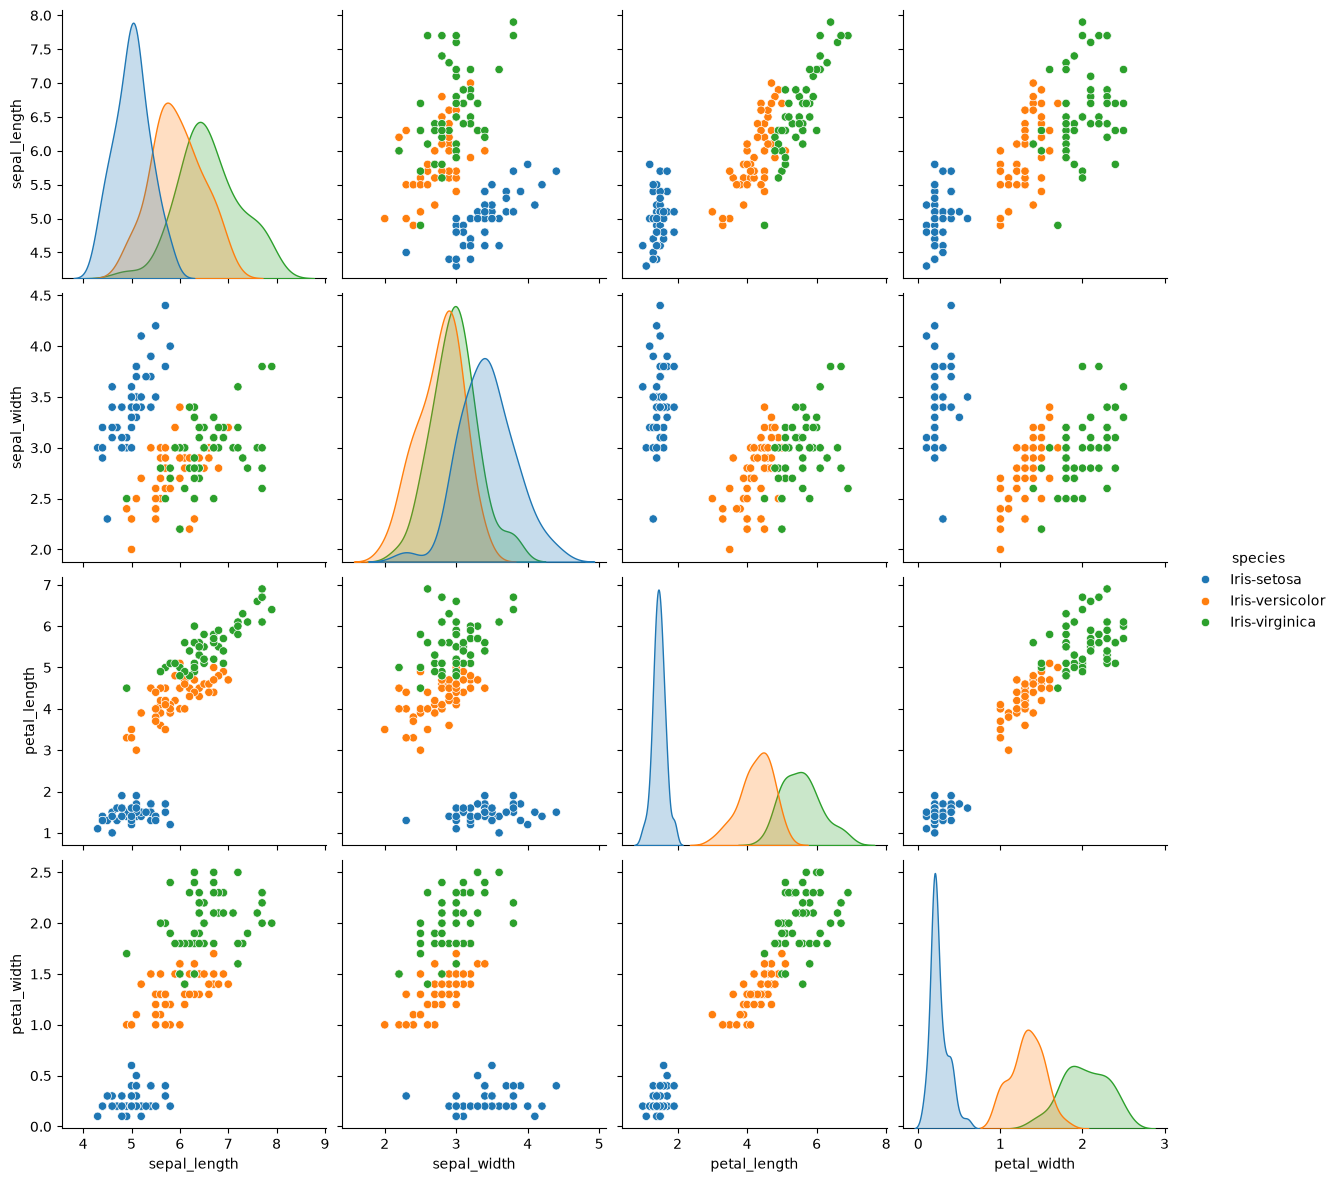

In [13]:
#-------------------------
## Pairplot Visualization Before Scaling
#------------------------
sns.pairplot(data=dataframe,hue='species',size=3)

### Feature Scaling

After finishing the visualizations, we need to scale the numeric features before applying K-Means.

We decided to perform scaling because the ratio between the highest and lowest standard deviation is approximately **4.1** (from the `describe()` output). 

This difference in scale can negatively affect distance-based algorithms like K-Means, so Standard Scaling is necessary.

In [14]:
#-------------------------
## Scaling Using StandardScaler
#------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_frame)
scaled_dataframe = DataFrame(scaled_features, columns=data_frame.columns)
scaled_dataframe

,sepal_length,sepal_width,petal_length,petal_width
0,-0.915509,1.019971,-1.357737,-1.335700
1,-1.157560,-0.128082,-1.357737,-1.335700
2,-1.399610,0.331139,-1.414778,-1.335700
3,-1.520635,0.101529,-1.300696,-1.335700
4,-1.036535,1.249582,-1.357737,-1.335700
...,...,...,...,...
142,1.020892,-0.128082,0.809831,1.444682
143,0.536792,-1.276136,0.695748,0.915085
144,0.778842,-0.128082,0.809831,1.047484
145,0.415766,0.790361,0.923913,1.444682


In [15]:
scaled_dataframe.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,1.470000e+02,1.470000e+02,1.470000e+02,1.470000e+02
mean,-4.833624e-17,1.691768e-16,-2.416812e-16,-3.383537e-16
std,1.003419e+00,1.003419e+00,1.003419e+00,1.003419e+00
min,-1.883710e+00,-2.424189e+00,-1.585902e+00,-1.468099e+00
25%,-9.155095e-01,-5.873036e-01,-1.243654e+00,-1.203301e+00
50%,-6.833389e-02,-1.280822e-01,3.535005e-01,1.206904e-01
75%,6.578166e-01,5.607500e-01,7.527893e-01,7.826860e-01
max,2.473193e+00,3.086468e+00,1.779532e+00,1.709480e+00


k = 2 | Inertia = 220.86 | Silhouette = 0.5792
k = 3 | Inertia = 138.26 | Silhouette = 0.4573
k = 4 | Inertia = 112.91 | Silhouette = 0.4152
k = 5 | Inertia = 89.89 | Silhouette = 0.3441
k = 6 | Inertia = 80.84 | Silhouette = 0.3416
k = 7 | Inertia = 70.01 | Silhouette = 0.3213
k = 8 | Inertia = 62.11 | Silhouette = 0.3349
k = 9 | Inertia = 54.11 | Silhouette = 0.3480
k = 10 | Inertia = 48.73 | Silhouette = 0.3485


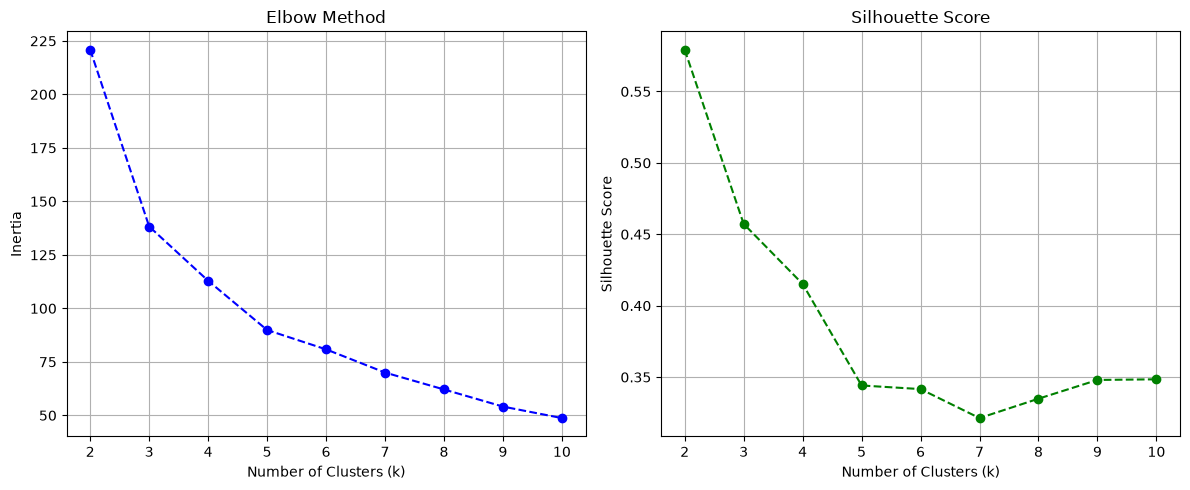

In [16]:
#-------------------------
## KMeans Training 
#------------------------

# Array To store Values
inertia_values = []
silhouette_scores = []
k_range = range(2, 11)   # From 2-10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_dataframe)
    
    # Inertia (Elbow)
    inertia_values.append(kmeans.inertia_)
    
    # Silhouette Score
    score = silhouette_score(scaled_dataframe, kmeans.labels_)
    silhouette_scores.append(score)
    
    print(f"k = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette = {score:.4f}")

# --------------------  Elbow Method --------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(True)

# --------------------  Silhouette Score --------------------
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='g')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
#-------------------------
## Find Best K
#-------------------------

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print(f"Best K based on Silhouette Score: {best_k}")

Best K based on Silhouette Score: 2


In [18]:
#-------------------------
## Final KMeans Model
#-------------------------

final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

final_kmeans.fit(scaled_dataframe)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 4)","[[-0.

In [19]:
#-------------------------
## Predict Clusters
#-------------------------

clusters = final_kmeans.predict(scaled_dataframe)

print(clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 2
 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2 2 2
 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 2 2 2 0 2 2 0]


In [20]:
#-------------------------
## Add Cluster Labels
#-------------------------

dataframe['cluster'] = clusters

display(dataframe.head())

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1


In [21]:
#-------------------------
## Final Silhouette Score
#-------------------------

final_silhouette = silhouette_score(
    scaled_dataframe,
    clusters
)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.4573


In [22]:
#-------------------------
## Compare With True Labels
#-------------------------

from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    dataframe['species'],
    dataframe['cluster']
)

print(f"ARI Score: {ari_score:.4f}")

ARI Score: 0.6202


In [23]:
#-------------------------
## Species vs Clusters
#-------------------------

comparison = crosstab(
    dataframe['species'],
    dataframe['cluster']
)

display(comparison)

cluster,0,1,2
species,,,
Iris-setosa,0,48,0
Iris-versicolor,39,0,11
Iris-virginica,13,0,36


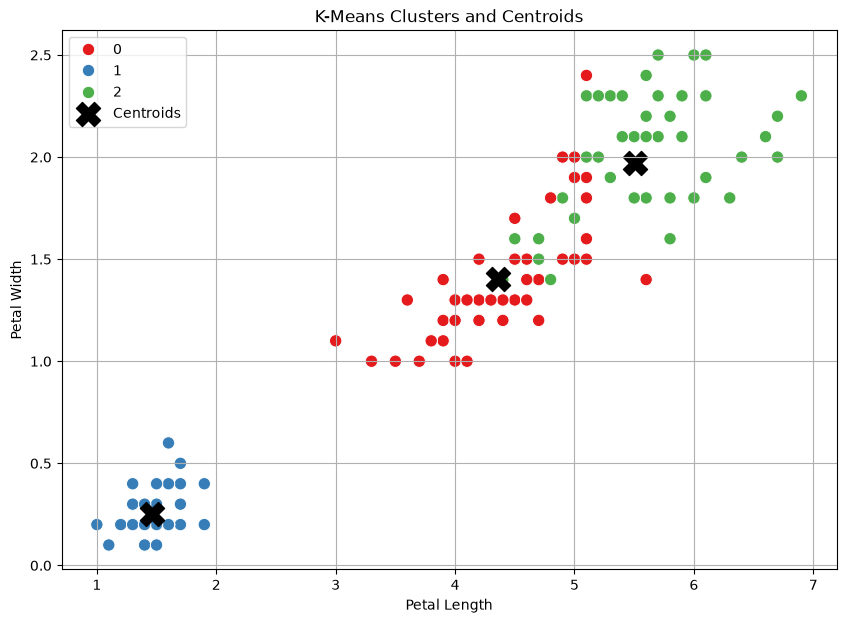

In [24]:
#-------------------------
## Clusters + Centroids
#-------------------------

plt.figure(figsize=(10, 7))

# Plot data points
sns.scatterplot(
    data=dataframe,
    x='petal_length',
    y='petal_width',
    hue='cluster',
    palette='Set1',
    s=80
)

# Get centroid coordinates
centers = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

# Plot centroids
plt.scatter(
    centers[:, 2],   # petal_length
    centers[:, 3],   # petal_width
    marker='X',
    s=300,
    color='black',
    label='Centroids'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clusters and Centroids')
plt.legend()
plt.grid(True)

plt.show()